In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sncosmo
# %pip install sfdmap2
# %pip install lightcurvelynx

In [51]:
import matplotlib.pyplot as plt
import lsdb
import numpy as np
from lightcurvelynx.astro_utils.mag_flux import flux2mag
from astropy.cosmology import Planck18
from astropy.coordinates import Distance
import astropy.units as u
from joblib import Parallel, delayed
import pandas as pd
from nested_pandas import read_parquet
import sncosmo
import nested_pandas as npd
from utils import nightly_coadd

from dask.distributed import Client

In [4]:
client = Client(n_workers=16, memory_limit="24 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35177 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:35177/status,
Dashboard: http://127.0.0.1:35177/status,Workers: 16
Total threads: 16,Total memory: 384.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45603,Workers: 0
Dashboard: http://127.0.0.1:35177/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38609,Total threads: 1
Dashboard: http://127.0.0.1:34967/status,Memory: 24.00 GiB
Nanny: tcp://127.0.0.1:41743,


In [5]:
import os
os.environ["SFD_DIR"] = "/astro/users/midai/sfdmap2/sfddata-master"

In [6]:
DDF = False
refit_salt = True

In [7]:
columns = ["median_reliability","max_snr","ndet","nbands","n_g","n_r","n_i","n_z","dt",
           "median_flux_diff_ratio","median_flux_diff_ratio_abs","_dist_arcsec"]
bins_map = {"median_flux_diff_ratio": np.linspace(0,5,20),
        "median_flux_diff_ratio_abs": np.linspace(0,1,20)}
if DDF:
    sncandid_filename = "sncandid_w_bazin_ddf"
else:
    sncandid_filename = "sncandid_w_bazin"
sncat_meta = lsdb.open_catalog(sncandid_filename,columns=columns)

In [8]:
len(sncat_meta)

1395743

In [9]:
snmeta = sncat_meta.random_sample(200)

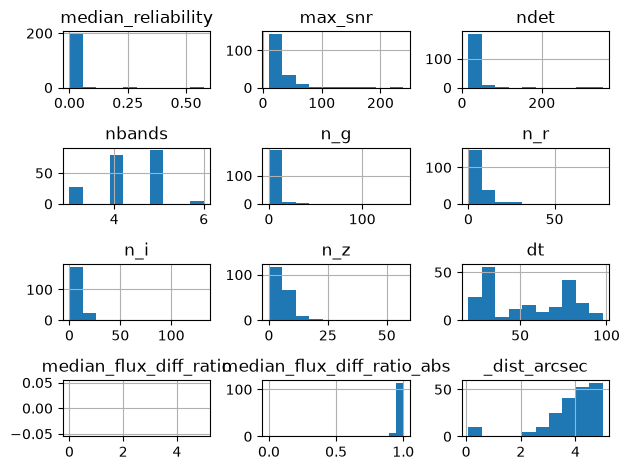

In [10]:
for i,col in enumerate(columns):
    plt.subplot(4,3,i+1)
    if col in bins_map.keys():
        bins = bins_map[col]
    else:
        bins = None
    snmeta[col].hist(bins=bins)
    plt.title(col)
plt.tight_layout()
plt.show()

In [11]:
bazin_cols = [f"bazin_fit_reduced_chi2_{b}" for b in "griz"]
sncat_bazin = lsdb.open_catalog(sncandid_filename,columns=bazin_cols)

In [12]:
snbazin = sncat_bazin.random_sample(200)

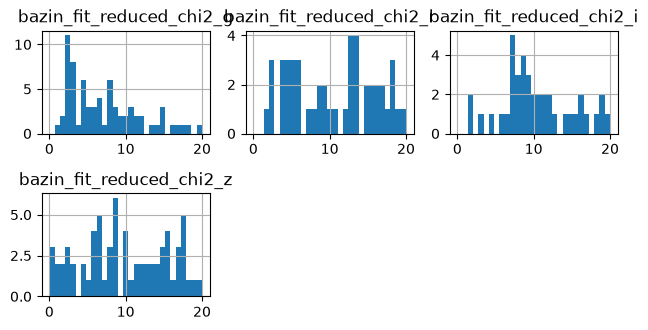

In [13]:
for i,col in enumerate(bazin_cols):
    plt.subplot(3,3,i+1)
    snbazin[col].hist(bins=np.linspace(0,20,30))
    plt.title(col)
plt.tight_layout()
plt.show()

In [14]:
sncat = lsdb.open_catalog(sncandid_filename)

In [15]:
def filter_bazin(df):
    df = df.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 20.0) or "
                  "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 20.0) or "
                  "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 20.0) or "
                  "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 20.0))")
    return df

In [16]:
sn_good = sncat.map_partitions(filter_bazin)

In [17]:
if DDF:
    goodsn_filename = "good_sne_ddf"
else:
    goodsn_filename = "good_sne"
print(goodsn_filename)

good_sne


In [18]:
sn_good.write_catalog(goodsn_filename,overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 50.01 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [81]:
sn_good = lsdb.open_catalog(goodsn_filename)

NameError: name 'goodsn_filename' is not defined

In [20]:
len(sn_good)

579567

In [21]:
head = sn_good.head()
head

In [7]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    plt.ylim(ylim)

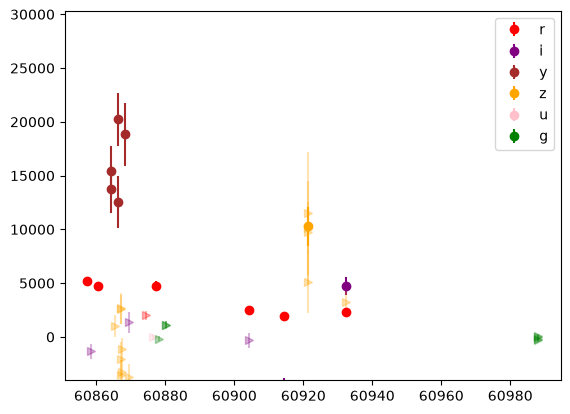

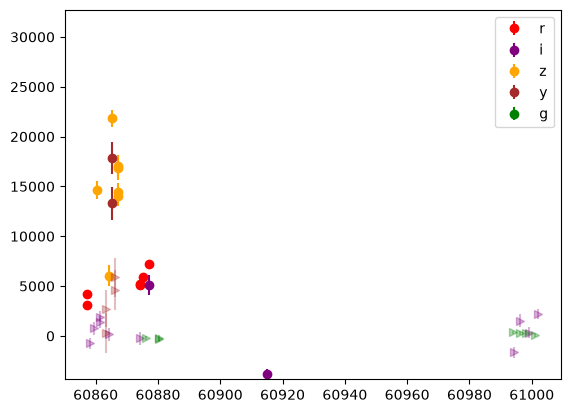

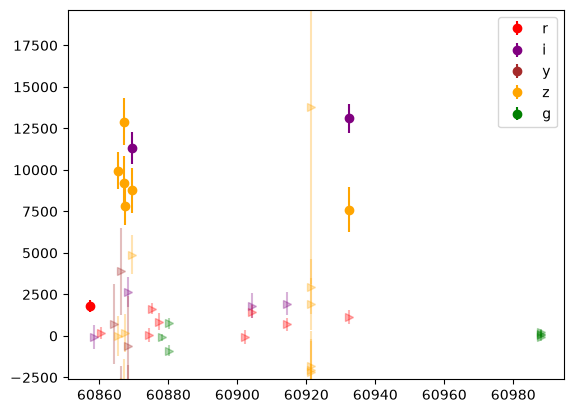

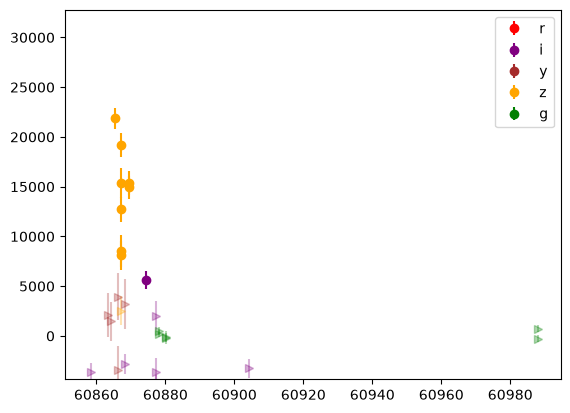

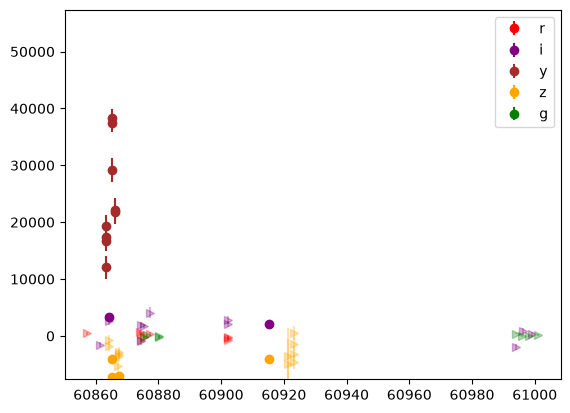

In [24]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [25]:
def lc_quality_cuts(flux,mjd,filter,snr, n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    det = snr > 5
    flux = flux[det]
    mjd = mjd[det]
    filter = filter[det]
    if len(flux) == 0:
        return {"pass_quality_cuts": False}
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx]))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -40) & (unique_phases<=100)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    good_phases = (phases >= -40) & (phases<=100)
    pass_cut &= len(np.unique(filter[good_phases])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [26]:
def make_lc_quality_cuts(df):
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in ["pass_quality_cut"]}) 
    else:
        df["diaObjectForcedSource_dia_object_lc.snr"] = df["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/df["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
        df = df.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                                       "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                                       "diaObjectForcedSource_dia_object_lc.band",
                                       "diaObjectForcedSource_dia_object_lc.snr"],
                                       row_container="args",output_names=["pass_quality_cut"], 
                                       append_columns=True)
    return df

In [27]:
sn_good_after_quality_cut = sn_good.map_partitions(make_lc_quality_cuts)

In [28]:
good_qc_filename = "good_sne_after_quality_cut"

In [29]:
sn_good_after_quality_cut = sn_good_after_quality_cut.query("pass_quality_cut == True")
sn_good_after_quality_cut.write_catalog(good_qc_filename,overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 24.70 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [30]:
sn_good_after_quality_cut = lsdb.open_catalog(good_qc_filename)
len(sn_good_after_quality_cut)

360066

In [31]:
head = sn_good_after_quality_cut.head()

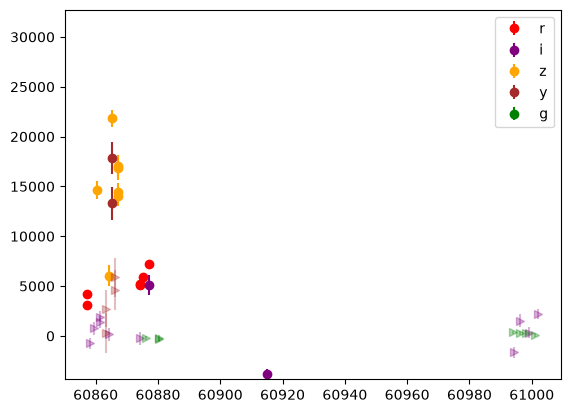

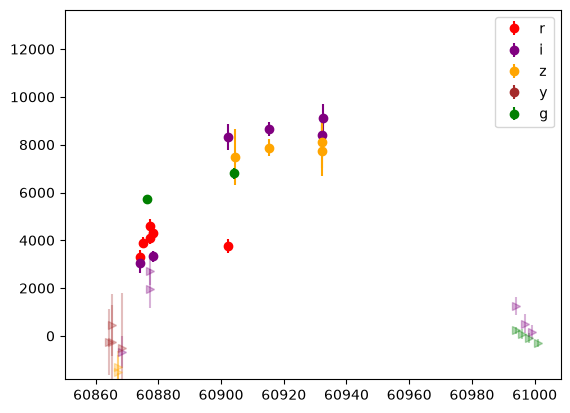

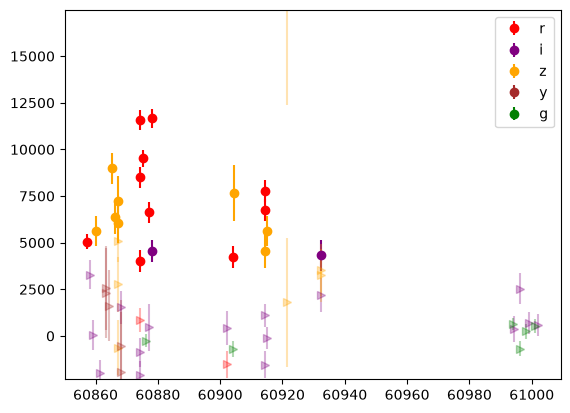

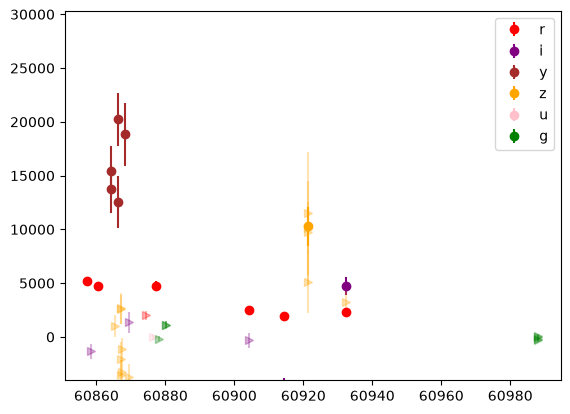

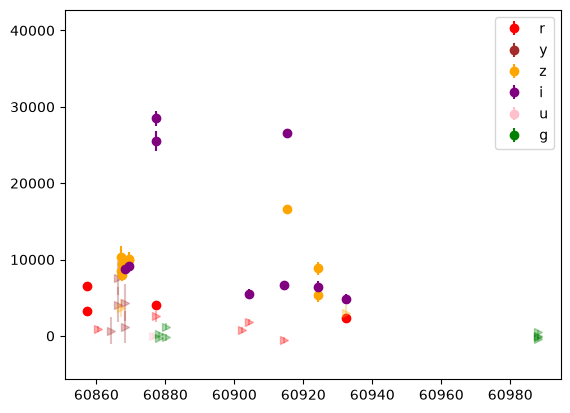

In [32]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [33]:
from lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.8),},
                         phase_range=(-15,45),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [34]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [35]:
def compute_z_from_peakmag(df):
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in ["z_est"]}) 
    else:
        df = df.map_rows(infer_z_from_peakmag, columns=["diaSource_dia_object_lc.psfFlux"], row_container="args",
                         output_names=["z_est"], append_columns=True)
    return df

In [36]:
def fit_salt2(df):
    saltcolumns = ['success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error']
    dtypes = [np.float64]*(len(saltcolumns)-2)+ [int] + [str]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=dtype) for name,dtype in zip(saltcolumns,dtypes)}) 
    else:
        df = df.map_rows(fit_single_lc_w_cond, 
                         columns=["ra_dia_object_lc","dec_dia_object_lc","diaObjectId_dia_object_lc", "z_est",
                                  "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                                  "diaSource_dia_object_lc.psfFlux","diaSource_dia_object_lc.psfFluxErr"], 
                         append_columns=True)
    return df

In [37]:
sn_good_after_quality_cut = lsdb.open_catalog(good_qc_filename)
sn_good_after_quality_cut = sn_good_after_quality_cut.map_partitions(compute_z_from_peakmag)

In [38]:
# # for debugging
# sn_good_after_quality_cut = sn_good_after_quality_cut.partitions[0:100]

In [39]:
res = sn_good_after_quality_cut.map_partitions(fit_salt2,compute_single_partition=False)

In [40]:
head = res.head()

In [41]:
head

diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1206701844133807939         773986573124370440        349.081428   
1218154719608123607         777320567257694253        357.320602   
1218213974998685157         778973889148485641        357.350255   
1218323371960852628         774003684274077713        352.294598   
1219070672650902806         775645048975917072        351.550362   

                     dec_dia_object_lc  \
_healpix_29                              
1206701844133807939         -11.594176   
1218154719608123607          -8.257355   
1218213974998685157          -7.437324   
1218323371960852628         -10.803756   
1219070672650902806          -9.451297   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1206701844133807939  [{midpointMjdTai: 60857.302557, band: 'r', psf...   
1218154719608123607  [{midpointMjdTai: 60857.345841, band: 'r', psf...   
1218213974998685157  [{midpointMjdTai: 60857.345841, band: 'r', psf...   
1218323371960852628  [{midpointMjdTai: 60857.341567, band: 'r', psf...   
1219070672650902806  [{midpointMjdTai: 60857.344377, band: 'r', psf...   

                                               diaSource_dia_object_lc  \
_healpix_29                                                              
1206701844133807939  [{midpointMjdTai: 60857.302557, band: 'r', psf...   
1218154719608123607  [{midpointMjdTai: 60858.312075, band: 'i', psf...   
1218213974998685157  [{midpointMjdTai: 60857.345841, band: 'r', psf...   
1218323371960852628  [{midpointMjdTai: 60857.341567, band: 'r', psf...   
1219070672650902806  [{midpointMjdTai: 60857.344377, band: 'r', psf...   

                     refExtendedness_object_lc  refSizeExtendedness_object_lc  \
_healpix_29                                                                     
1206701844133807939                        1.0                            1.0   
1218154719608123607                        1.0                       0.997092   
1218213974998685157                        1.0                       0.999894   
1218323371960852628                        1.0                            1.0   
1219070672650902806                        1.0                            1.0   

                     objectId_object_lc  coord_ra_object_lc  \
_healpix_29                                                   
1206701844133807939  773986573124390309          349.081166   
1218154719608123607  777320567257713787          357.320253   
1218213974998685157  778973889148506234          357.350347   
1218323371960852628  774003684274095345          352.294601   
1219070672650902806  775645048975937099          351.550389   

                     coord_dec_object_lc  ...       c_c_cov  c_mwebv_cov  \
_healpix_29                               ...                              
1206701844133807939           -11.593203  ...  8.148338e-19          0.0   
1218154719608123607             -8.25824  ...  1.566028e-11          0.0   
1218213974998685157            -7.436459  ...  5.384703e-14          0.0   
1218323371960852628           -10.804017  ...  1.987028e-03          0.0   
1219070672650902806            -9.451294  ...  8.945596e-03          0.0   

                     mwebv_z_cov  mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  \
_healpix_29                                                                  
1206701844133807939          0.0           0.0           0.0           0.0   
1218154719608123607          0.0           0.0           0.0           0.0   
1218213974998685157          0.0           0.0           0.0           0.0   
1218323371960852628          0.0           0.0           0.0           0.0   
1219070672650902806          0.0           0.0           0.0           0.0   

                     mwebv_c_cov  mwebv_mwebv_cov                  id  \
_healpix_29                                     

In [42]:
if refit_salt:
    res.write_catalog("saltfit_on_good_sne_after_quality_cut",overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 26.50 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting

In [29]:
columns = ['diaObjectId_dia_object_lc','success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error', 'diaSource_dia_object_lc',
           'diaObjectForcedSource_dia_object_lc','_dist_arcsec']
saltres = lsdb.open_catalog("saltfit_on_good_sne_after_quality_cut",columns=columns)
len(saltres)

360066

In [30]:
saltres.columns

Index(['diaObjectId_dia_object_lc', 'success', 'ncall', 'chisq', 'ndof', 'z',
       'z_err', 't0', 't0_err', 'x0', 'x0_err', 'x1', 'x1_err', 'c', 'c_err',
       'mwebv', 'mwebv_err', 'z_z_cov', 'z_t0_cov', 'z_x0_cov', 'z_x1_cov',
       'z_c_cov', 'z_mwebv_cov', 't0_z_cov', 't0_t0_cov', 't0_x0_cov',
       't0_x1_cov', 't0_c_cov', 't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov',
       'x0_x0_cov', 'x0_x1_cov', 'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov',
       'x1_t0_cov', 'x1_x0_cov', 'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov',
       'c_z_cov', 'c_t0_cov', 'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov',
       'mwebv_z_cov', 'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov',
       'mwebv_c_cov', 'mwebv_mwebv_cov', 'id', 'fit_error',
       'diaSource_dia_object_lc', 'diaObjectForcedSource_dia_object_lc',
       '_dist_arcsec', 'ra_dia_object_lc', 'dec_dia_object_lc'],
      dtype='object')

In [31]:
saltres = saltres.query("success == 1 and "
                        "(x1 > -3.99 and x1 < 3.99) and " 
                        "(c > -0.399 and c < 0.799) and "
                        "mwebv < 0.25")
saltres.write_catalog("saltfit_on_good_sne_after_quality_cut_and_saltpar_cut",overwrite=True)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 17.50 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [82]:
saltres = lsdb.open_catalog("saltfit_on_good_sne_after_quality_cut_and_saltpar_cut")

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - dia_object_lc_x_object_lc'}>)

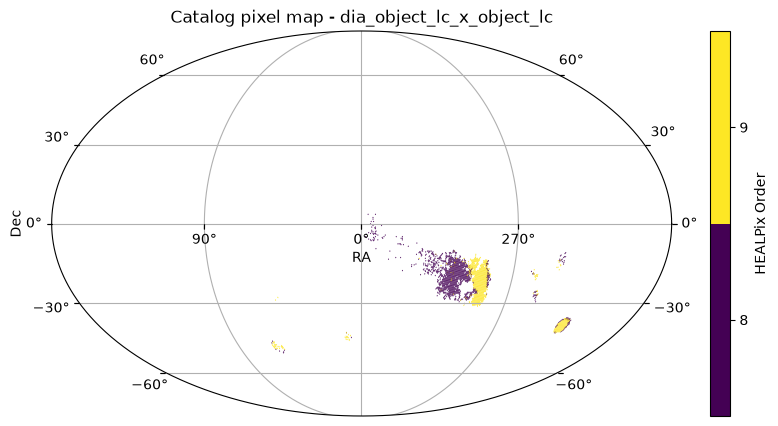

In [83]:
saltres.plot_pixels()

In [84]:
result_good = saltres.compute()

Task exception was never retrieved
future: <Task finished name='Task-6401758' coro=<Client._gather.<locals>.wait() done, defined at /astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py:2367> exception=AllExit()>
Traceback (most recent call last):
  File "/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/client.py", line 2376, in wait
    raise AllExit()
distributed.client.AllExit

KeyboardInterrupt



KeyboardInterrupt: 

In [85]:
if DDF:
    res_filename = "saltfit_good_sne_ddf.parquet"
else:
    res_filename = "saltfit_good_sne.parquet"

In [36]:
result_good.to_parquet(res_filename)

In [86]:
result_good = npd.read_parquet(res_filename)

In [87]:
result_good

diaObjectId_dia_object_lc  success  ncall       chisq  ndof         z  \
0             775645048975917072      1.0  179.0  325.672836  12.0  0.565905   
1             778958221107789854      1.0   64.0         0.0  -4.0  0.402129   
...                          ...      ...    ...         ...   ...       ...   
18227         775436279205593451      1.0  185.0         0.0  -4.0  0.104897   
18228         775436210486116688      1.0  611.0   87.442035  10.0  0.034782   

          z_err            t0      t0_err        x0  ...  mwebv_c_cov  \
0      0.029861  60877.956615    0.589063  0.000038  ...          0.0   
1      0.413606  60803.810431  153.430851 -0.000346  ...          0.0   
...         ...           ...         ...       ...  ...          ...   
18227  0.325631  60895.541527    6.382639  0.000099  ...          0.0   
18228  0.009578  60865.132659    0.441239  0.000048  ...          0.0   

       mwebv_mwebv_cov                  id  fit_error  \
0                  0.0  775645048975917072       None   
1                  0.0  778958221107789854       None   
...                ...                 ...        ...   
18227              0.0  775436279205593451       None   
18228              0.0  775436210486116688       None   

                                 diaSource_dia_object_lc  \
0      [{midpointMjdTai: 60857.344377, band: 'r', psf...   
1      [{midpointMjdTai: 60857.345321, band: 'r', psf...   
...                                                  ...   
18227  [{midpointMjdTai: 60847.28033, band: 'r', psfF...   
18228  [{midpointMjdTai: 60847.28033, band: 'r', psfF...   

                     diaObjectForcedSource_dia_object_lc  _dist_arcsec  \
0      [{midpointMjdTai: 60857.344377, band: 'r', psf...      0.095331   
1      [{midpointMjdTai: 60857.345321, band: 'r', psf...      4.345486   
...                                                  ...           ...   
18227  [{midpointMjdTai: 60847.256083, band: 'i', psf...      4.882212   
18228  [{midpointMjdTai: 60847.256083, band: 'i', psf...      4.567581   

       ra_dia_object_lc  dec_dia_object_lc          _healpix_29  
0            351.550362          -9.451297  1219070672650902806  
1            352.690425          -6.328285  1220187569101325359  
...                 ...                ...                  ...  
18227        306.277721         -10.061737  3452270320403528439  
18228         306.45633         -10.011917  3452276186256569580  

[18229 rows x 61 columns]

<Axes: >

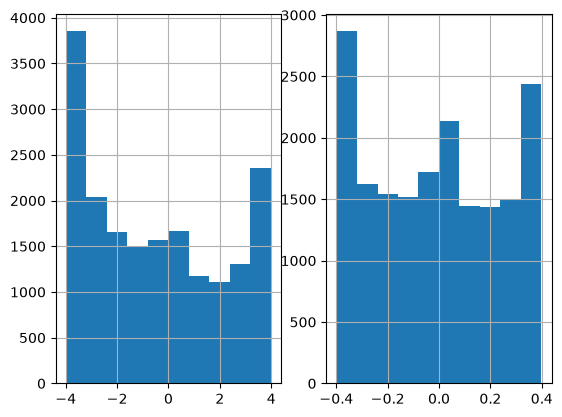

In [88]:
plt.subplot(1,2,1)
result_good.x1.hist()
plt.subplot(1,2,2)
result_good.c.hist()

In [89]:
result_good["reduced_chisq"] = result_good.chisq / result_good.ndof

<Axes: >

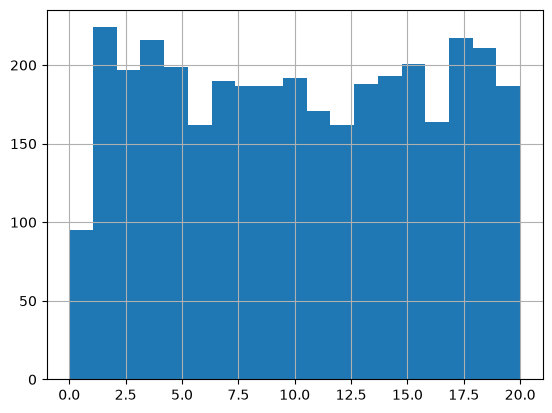

In [90]:
result_good.reduced_chisq.hist(bins = np.linspace(0, 20, 20))

In [91]:
sn_good = result_good.loc[(result_good.reduced_chisq > 0.01) & (result_good.reduced_chisq < 5.)]
# sn_good = sn_good.loc[(sn_good.x1 > -3.) & (sn_good.x1 < 3.) & (sn_good.c > -0.3) & (sn_good.c < 0.3)]

In [92]:
sn_good

diaObjectId_dia_object_lc  success  ncall      chisq  ndof         z  \
13            772323012031545366      1.0  126.0  33.748899  11.0  0.252418   
14            775608215336386996      1.0  224.0  26.259459  16.0  0.282632   
...                          ...      ...    ...        ...   ...       ...   
18143         772158291445809236      1.0  155.0  16.136233   5.0  0.470225   
18161         772168668086796457      1.0  181.0   1.163957   1.0  0.454241   

          z_err            t0    t0_err        x0  ...  mwebv_mwebv_cov  \
13     0.009704  60899.314772  0.282902  0.000091  ...              0.0   
14     0.024804  60909.672037  0.321134  0.000045  ...              0.0   
...         ...           ...       ...       ...  ...              ...   
18143  0.004225  60809.723915   0.96248  0.000388  ...              0.0   
18161  0.027388  60816.412895  2.794006  0.000948  ...              0.0   

                       id  fit_error  \
13     772323012031545366       None   
14     775608215336386996       None   
...                   ...        ...   
18143  772158291445809236       None   
18161  772168668086796457       None   

                                 diaSource_dia_object_lc  \
13     [{midpointMjdTai: 60858.283213, band: 'r', psf...   
14     [{midpointMjdTai: 60900.375942, band: 'i', psf...   
...                                                  ...   
18143  [{midpointMjdTai: 60847.237169, band: 'i', psf...   
18161  [{midpointMjdTai: 60847.27984, band: 'r', psfF...   

                     diaObjectForcedSource_dia_object_lc  _dist_arcsec  \
13     [{midpointMjdTai: 60858.283213, band: 'r', psf...      0.106734   
14     [{midpointMjdTai: 60859.380132, band: 'i', psf...       4.03985   
...                                                  ...           ...   
18143  [{midpointMjdTai: 60847.237169, band: 'i', psf...      4.698552   
18161  [{midpointMjdTai: 60847.255604, band: 'i', psf...      3.962686   

       ra_dia_object_lc  dec_dia_object_lc          _healpix_29  reduced_chisq  
13           344.062653         -13.212534  1301639150157111366       3.068082  
14           343.480496         -10.129434  1302626881764370315       1.641216  
...                 ...                ...                  ...            ...  
18143        308.780908         -13.026099  3449955926938461906       3.227247  
18161        310.183116         -12.303027  3450187026918380805       1.163957  

[875 rows x 62 columns]

<Axes: >

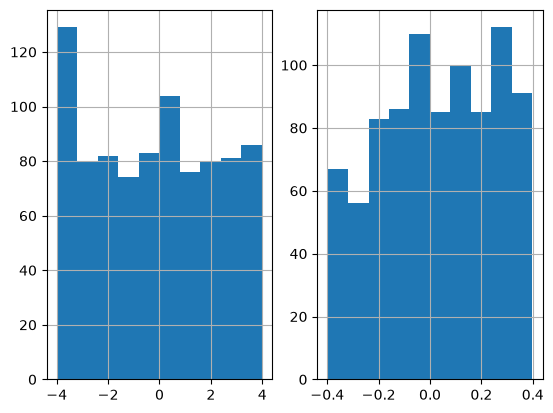

In [93]:
plt.subplot(1,2,1)
sn_good.x1.hist()
plt.subplot(1,2,2)
sn_good.c.hist()

In [94]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[(phases >=-10) & (phases <=40)])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [95]:
sn = sn_good

In [96]:
sn["diaObjectForcedSource_dia_object_lc.snr"] = sn["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/sn["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
sn_det = sn.query("diaObjectForcedSource_dia_object_lc.snr > 5")
pass_quality_cut = sn_det.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                               "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                               "diaObjectForcedSource_dia_object_lc.band","z","t0"],
                               row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
sn["pass_quality_cuts"] = False
sn.loc[idx,"pass_quality_cuts"] = True
sn = sn[sn["pass_quality_cuts"] == True]

In [97]:
sn

diaObjectId_dia_object_lc  success  ncall      chisq  ndof         z  \
13            772323012031545366      1.0  126.0  33.748899  11.0  0.252418   
14            775608215336386996      1.0  224.0  26.259459  16.0  0.282632   
...                          ...      ...    ...        ...   ...       ...   
18073         770546132521582641      1.0  207.0  33.901064   8.0  0.570479   
18095         770585989818089516      1.0  441.0  11.188734   4.0  0.404302   

          z_err            t0    t0_err        x0  ...                  id  \
13     0.009704  60899.314772  0.282902  0.000091  ...  772323012031545366   
14     0.024804  60909.672037  0.321134  0.000045  ...  775608215336386996   
...         ...           ...       ...       ...  ...                 ...   
18073  0.020552  60889.849313  0.279856  0.000068  ...  770546132521582641   
18095   0.02226  60892.404374  0.539875  0.000052  ...  770585989818089516   

       fit_error                            diaSource_dia_object_lc  \
13          None  [{midpointMjdTai: 60858.283213, band: 'r', psf...   
14          None  [{midpointMjdTai: 60900.375942, band: 'i', psf...   
...          ...                                                ...   
18073       None  [{midpointMjdTai: 60847.237627, band: 'i', psf...   
18095       None  [{midpointMjdTai: 60831.297489, band: 'i', psf...   

                     diaObjectForcedSource_dia_object_lc  _dist_arcsec  \
13     [{midpointMjdTai: 60858.283213, band: 'r', psf...      0.106734   
14     [{midpointMjdTai: 60859.380132, band: 'i', psf...       4.03985   
...                                                  ...           ...   
18073  [{midpointMjdTai: 60847.237627, band: 'i', psf...      4.928803   
18095  [{midpointMjdTai: 60831.297489, band: 'i', psf...      0.102808   

       ra_dia_object_lc  dec_dia_object_lc          _healpix_29  \
13           344.062653         -13.212534  1301639150157111366   
14           343.480496         -10.129434  1302626881764370315   
...                 ...                ...                  ...   
18073         311.60385         -13.907936  3443892606033761594   
18095        320.738773         -14.260858  3445258801680769934   

       reduced_chisq  pass_quality_cuts  
13          3.068082               True  
14          1.641216               True  
...              ...                ...  
18073       4.237633               True  
18095       2.797183               True  

[385 rows x 63 columns]

{'x0': 4.702903887826897e-05, 'x1': -0.7463869770208523, 'c': 0.2493667836052535, 'z': 0.4493808815877664, 'mwebv': 0.15333657841170456, 't0': 60883.01830347621}
dist,reduced_chi2= 3.291488940217412 1.7781405257028224


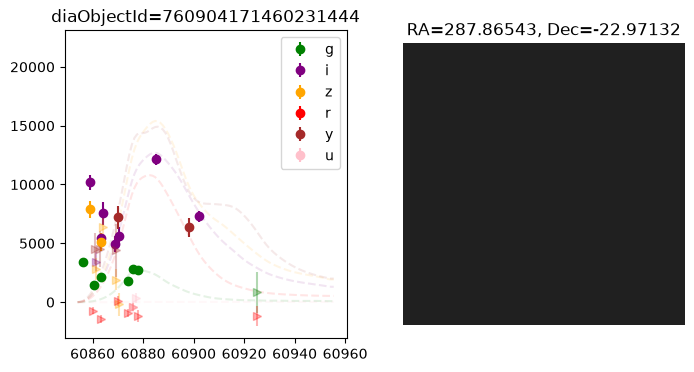

{'x0': 1.2945246554443615e-05, 'x1': -1.4768310453186044, 'c': 0.35394700890185643, 'z': 0.31352869027146274, 'mwebv': 0.09248214311417607, 't0': 60864.935402338546}
dist,reduced_chi2= 4.094889321128744 3.1574448743804577


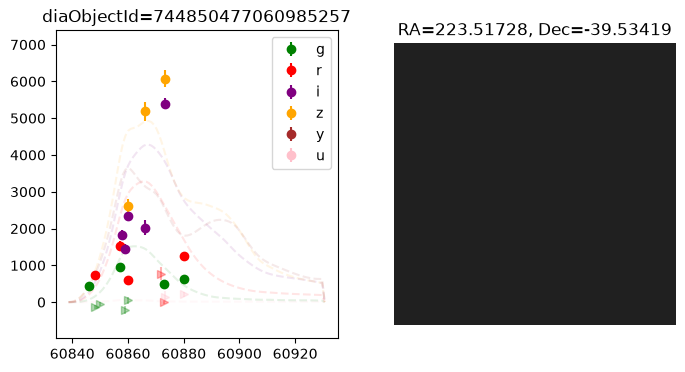

{'x0': 1.0721483945601103e-05, 'x1': 0.3782555207433839, 'c': -0.0774903356657675, 'z': 0.314468035821119, 'mwebv': 0.0051558707836493, 't0': 60865.677822376696}
dist,reduced_chi2= 0.3284534922146671 0.925599858399018


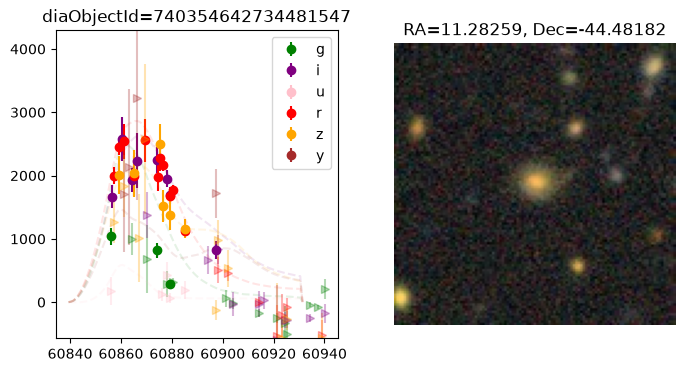

{'x0': 2.7023347388689485e-05, 'x1': 0.5339079141639869, 'c': -0.18672303949117502, 'z': 0.6420693992777913, 'mwebv': 0.13556015199722163, 't0': 60877.13435075794}
dist,reduced_chi2= 4.373275354469967 3.81307189383099


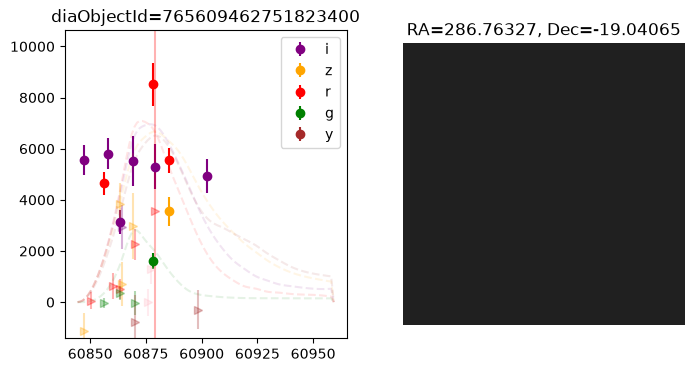

{'x0': -2.6374102611549217e-05, 'x1': -2.8009955489584653, 'c': -0.08340520873944071, 'z': 0.49738764811900493, 'mwebv': 0.07005518230318321, 't0': 60868.68170162721}
dist,reduced_chi2= 4.48817292743315 3.382697346297605


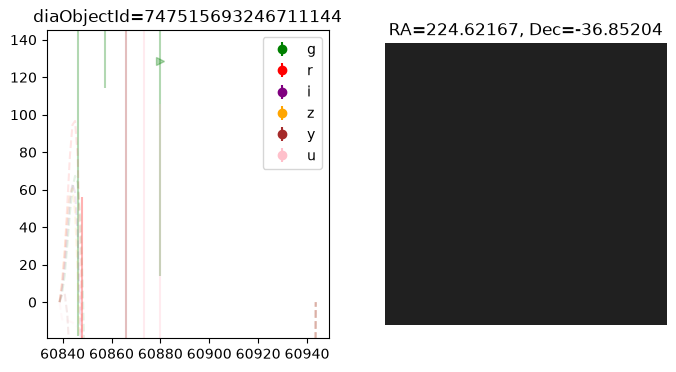

{'x0': 1.7735356018545176e-05, 'x1': 0.2912473576929298, 'c': 0.15251708612252932, 'z': 0.16964757827380195, 'mwebv': 0.08215935311142827, 't0': 60865.0437104987}
dist,reduced_chi2= 4.949983538924932 4.0211049840172945


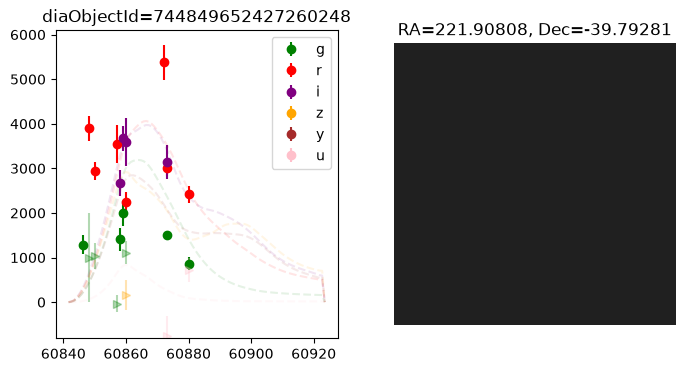

{'x0': 1.6033025717590947e-05, 'x1': 3.527776481273361, 'c': -0.04471238846072638, 'z': 0.27202681489247704, 'mwebv': 0.07339537460115789, 't0': 60861.30830202974}
dist,reduced_chi2= 4.100409263732504 3.3747892337654917


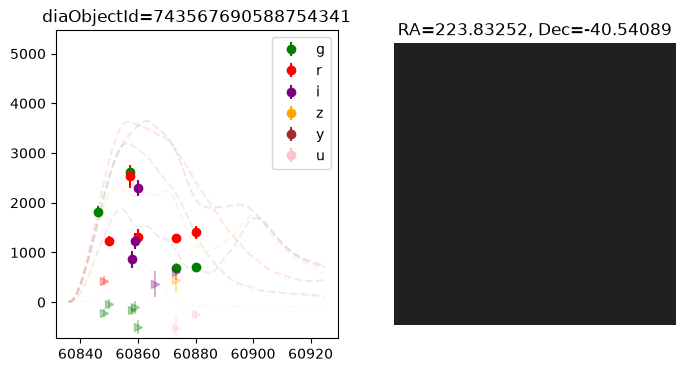

{'x0': 8.991353298724714e-06, 'x1': 3.8456088561892336, 'c': -0.12604501061477694, 'z': 0.18337103378801692, 'mwebv': 0.06315186526555921, 't0': 60867.43617097562}
dist,reduced_chi2= 4.359705882839256 1.9681412031242769


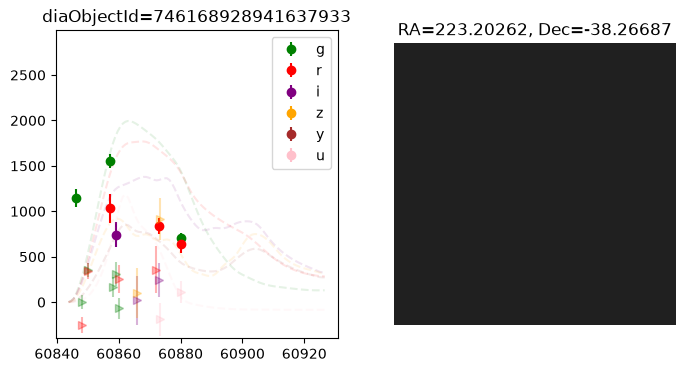

{'x0': 1.3738841488201949e-05, 'x1': -2.283219372116958, 'c': 0.1749053495280353, 'z': 0.2993731503693464, 'mwebv': 0.0707046214436954, 't0': 60863.27216857112}
dist,reduced_chi2= 3.879125693527739 3.1993923749030606


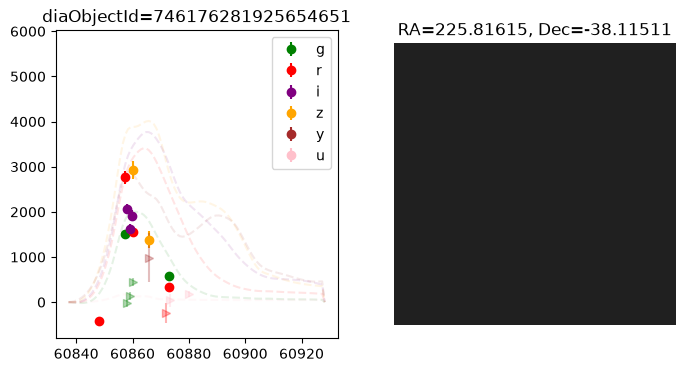

{'x0': 2.26776900662104e-05, 'x1': 0.6270154321803831, 'c': 0.3237766597015648, 'z': 0.3225217713138763, 'mwebv': 0.0712751849292179, 't0': 60868.25282331845}
dist,reduced_chi2= 2.7423388068295336 2.596787035513501


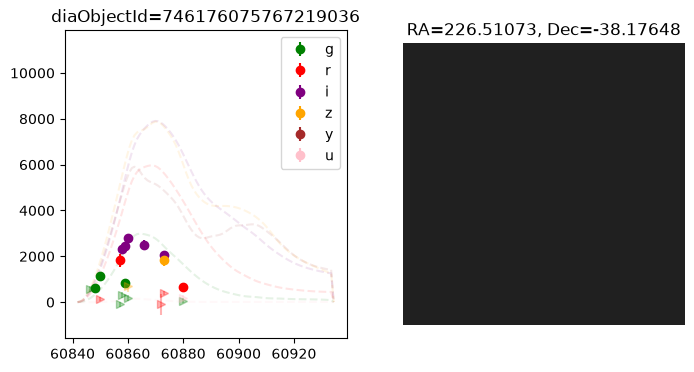

{'x0': 1.694654444215117e-05, 'x1': -0.028900490964093084, 'c': 0.2751853205141592, 'z': 0.31600198583918226, 'mwebv': 0.09511673436653764, 't0': 60863.79219604045}
dist,reduced_chi2= 4.471899984065218 1.7614188050860577


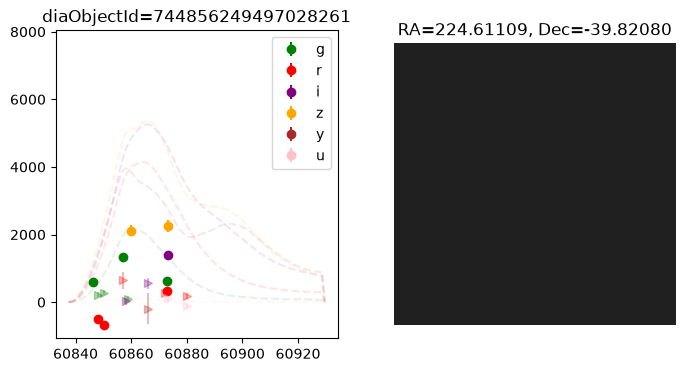

{'x0': 1.0477978908080936e-05, 'x1': -0.11558773236394185, 'c': 0.3927170901352624, 'z': 0.2816515507614714, 'mwebv': 0.09270265390591871, 't0': 60866.97427061793}
dist,reduced_chi2= 3.635059911477632 2.2454226502742176


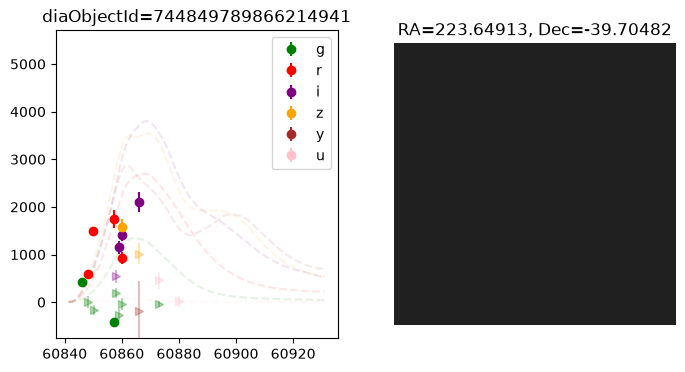

{'x0': 3.129846655976064e-05, 'x1': -1.460931370658335, 'c': 0.35332754271367145, 'z': 0.18813616758842994, 'mwebv': 0.07217444433389562, 't0': 60840.318670691966}
dist,reduced_chi2= 4.5841680073356885 2.2587700437365887


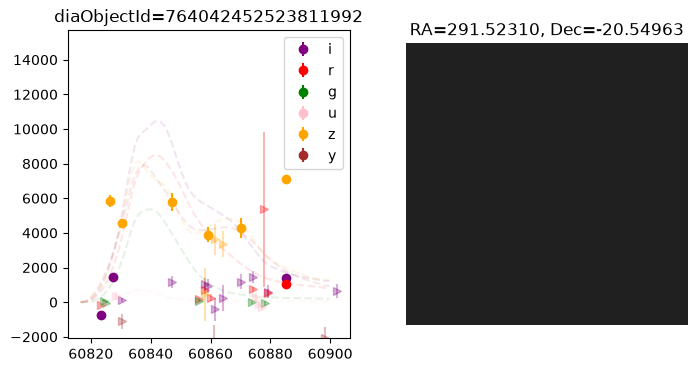

{'x0': 1.4618777244710722e-05, 'x1': 1.9559487824932442, 'c': 0.3889157500551882, 'z': 0.6134769669400693, 'mwebv': 0.07261764432464812, 't0': 60862.353708003524}
dist,reduced_chi2= 0.1264160647423162 0.7331418214880988


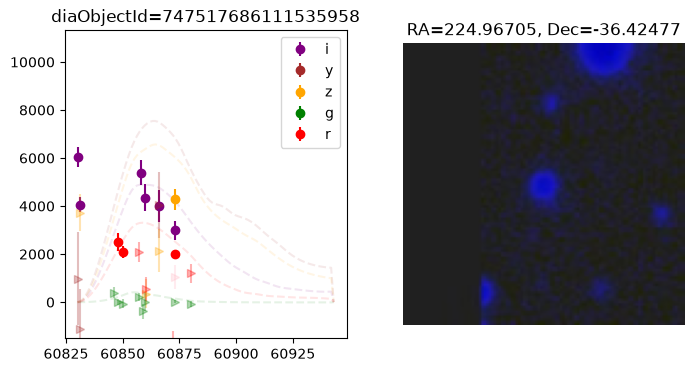

{'x0': 9.437508871431075e-05, 'x1': -1.384849173586764, 'c': -0.26288830800286106, 'z': 0.1388857256390722, 'mwebv': 0.15168448800094322, 't0': 60834.07867368012}
dist,reduced_chi2= 4.089026698629962 4.870401226900436


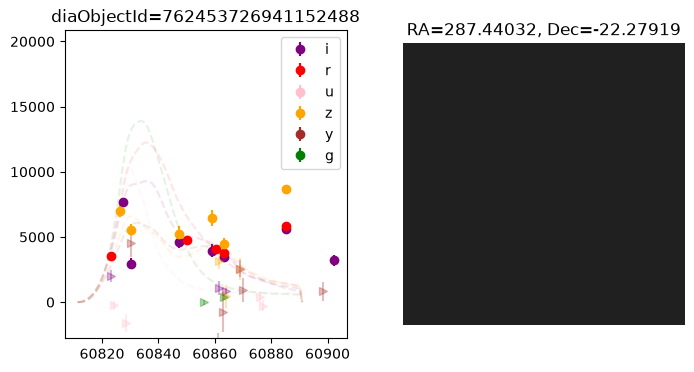

{'x0': 1.2999929182383276e-05, 'x1': 3.297483581014732, 'c': 0.2085984228986938, 'z': 0.13098200833087303, 'mwebv': 0.0777047333026743, 't0': 60867.65171015158}
dist,reduced_chi2= 4.61967270665205 1.9810595830734141


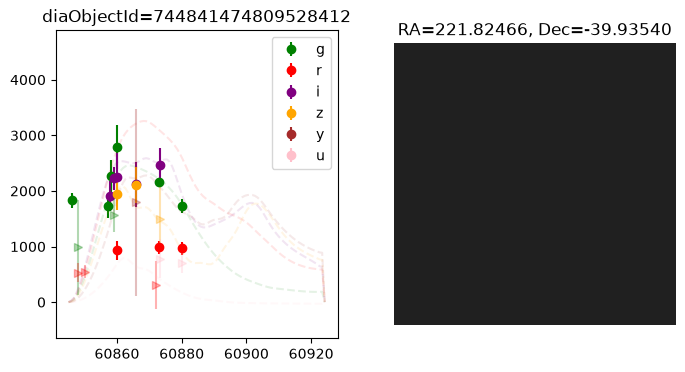

{'x0': 1.7651623257042368e-05, 'x1': 2.0105047000947787, 'c': 0.28145798801065186, 'z': 0.3507919421408106, 'mwebv': 0.1268848711647258, 't0': 60862.460427534046}
dist,reduced_chi2= 3.3937331196289033 4.134205061284053


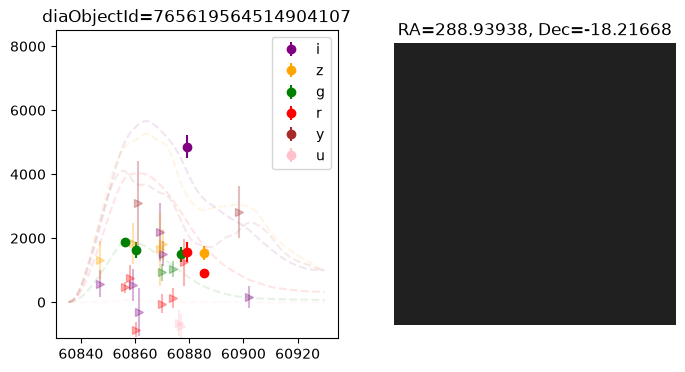

{'x0': 2.0124000515172478e-05, 'x1': -0.4837495690294783, 'c': 0.0005432215893532033, 'z': 0.6283601502562632, 'mwebv': 0.07303658056392079, 't0': 60863.29152698603}
dist,reduced_chi2= 4.793059457385644 4.99798159582991


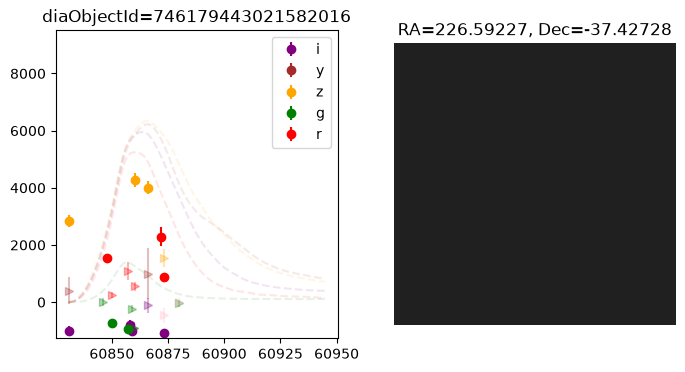

{'x0': 2.065382219294026e-05, 'x1': -0.264773575606823, 'c': 0.08488577005931032, 'z': 0.3790587516952906, 'mwebv': 0.06463482314971872, 't0': 60866.25440354349}
dist,reduced_chi2= 4.515172344293621 2.10694153436481


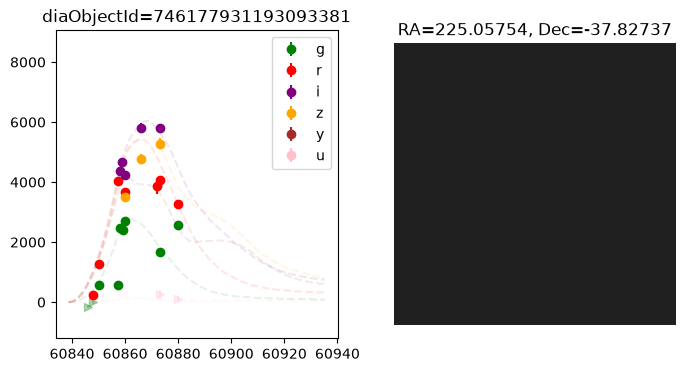

{'x0': 1.349107803700092e-05, 'x1': -1.9694101123534649, 'c': -0.0022079732470045212, 'z': 0.3039139556361759, 'mwebv': 0.08782107860534623, 't0': 60864.05815262502}
dist,reduced_chi2= 0.9218719935258326 3.3145312254081896


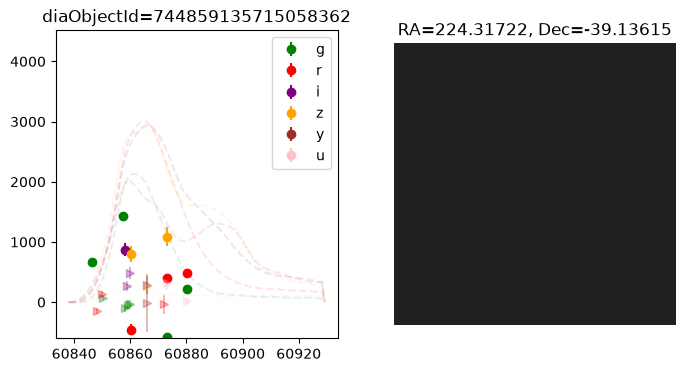

{'x0': 1.5698309584656604e-05, 'x1': 3.0707820703443707, 'c': -0.13810708854137738, 'z': 0.3285088803386496, 'mwebv': 0.0653899326470529, 't0': 60871.62256122449}
dist,reduced_chi2= 4.950299743079423 2.432445165991278


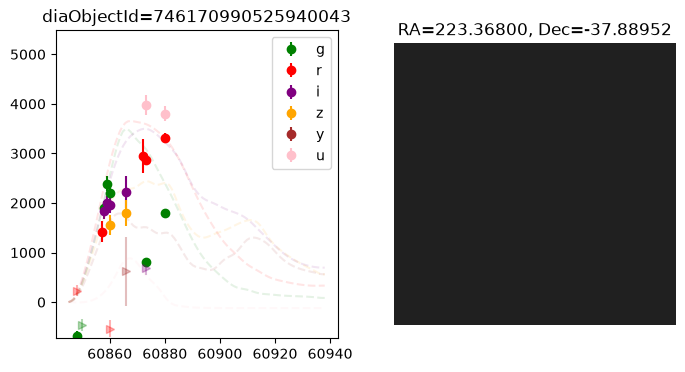

{'x0': 3.202803328380186e-05, 'x1': 0.5336968806330589, 'c': -0.20293153534961028, 'z': 0.11577500385495826, 'mwebv': 0.0843376416927573, 't0': 60856.878026591665}
dist,reduced_chi2= 0.8478051221643373 4.354192722967621


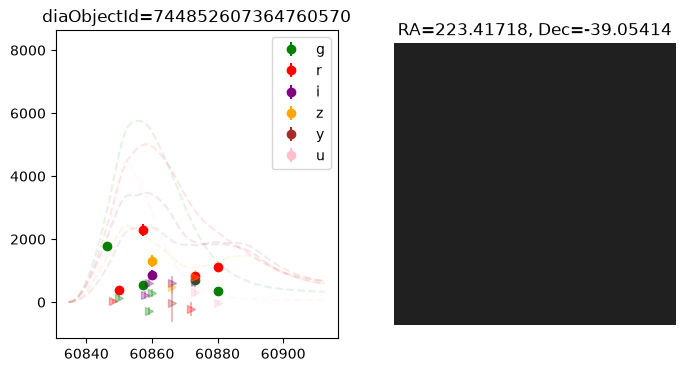

{'x0': 1.9483222196917214e-05, 'x1': -0.5797186176122306, 'c': -0.06212419976142313, 'z': 0.5273071041605703, 'mwebv': 0.06897943823327589, 't0': 60862.8863062479}
dist,reduced_chi2= 3.9987725322748844 4.539617763109857


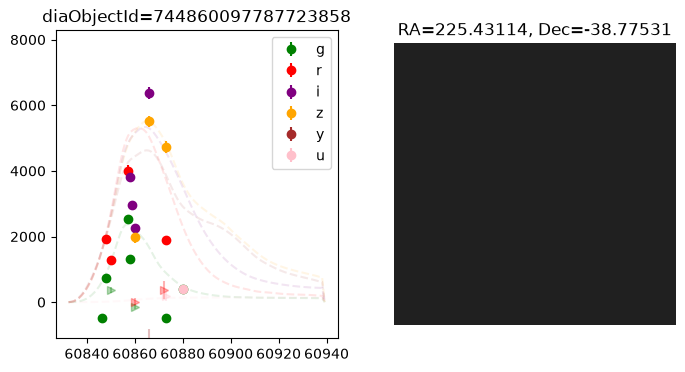

{'x0': 3.279120469480319e-05, 'x1': 0.6182342564065754, 'c': 0.19958139417306361, 'z': 0.09155041839613924, 'mwebv': 0.074933452445819, 't0': 60840.401725715004}
dist,reduced_chi2= 4.987824983157333 1.494547665189


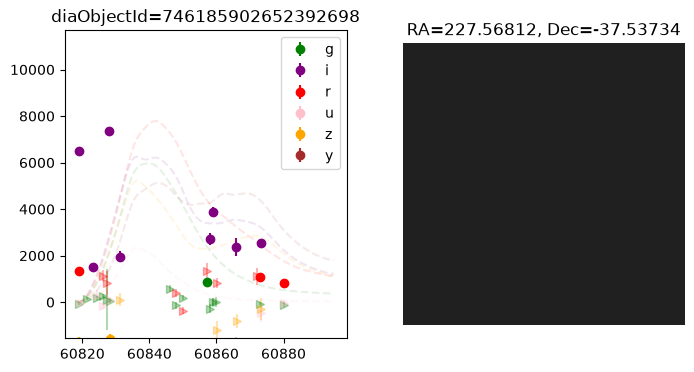

{'x0': 1.3011076191724535e-05, 'x1': 3.3120328886284693, 'c': -0.1022889899851002, 'z': 0.46815284299210785, 'mwebv': 0.08277082094768698, 't0': 60868.71539781061}
dist,reduced_chi2= 4.630607036848482 2.1721494531489496


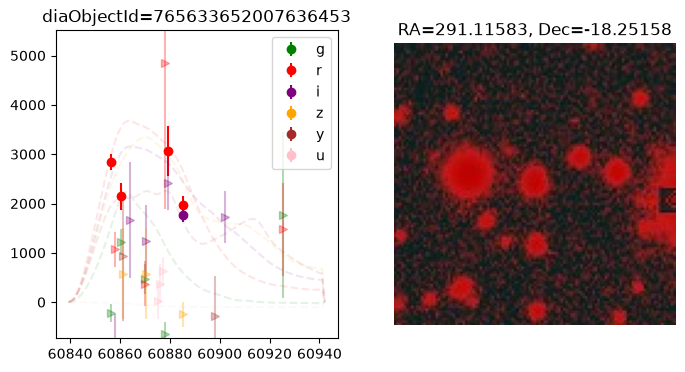

{'x0': 1.1724556227726425e-05, 'x1': 2.0891483292409863, 'c': -0.07265662910460222, 'z': 0.43694873407103385, 'mwebv': 0.006334489772994117, 't0': 60877.52775042146}
dist,reduced_chi2= 2.7015196157381327 1.0324223342070953


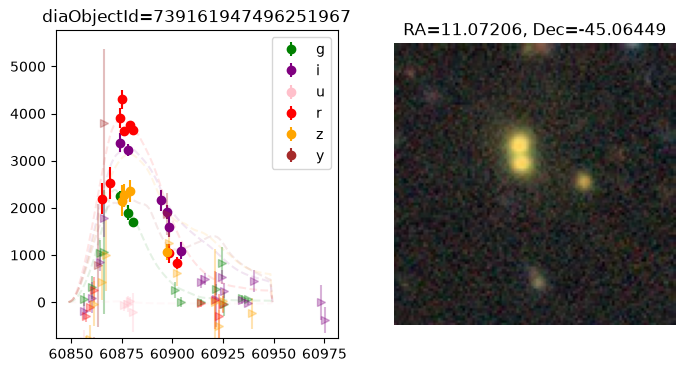

{'x0': 1.2496186182411944e-05, 'x1': -3.843165619956764, 'c': -0.26683285570332826, 'z': 0.6932228888615684, 'mwebv': 0.07920053268610525, 't0': 60867.96621945478}
dist,reduced_chi2= 0.4969289160298507 3.673818307551861


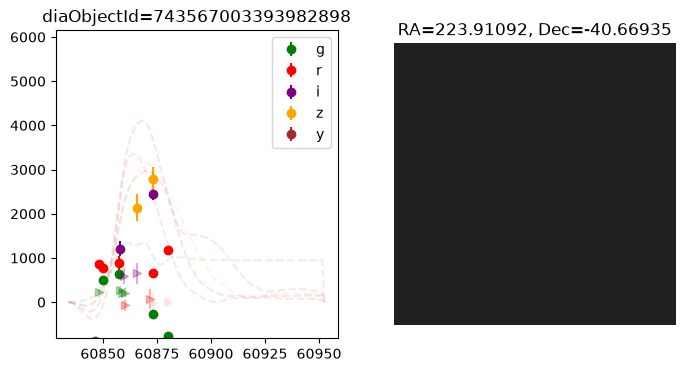

{'x0': 4.310043531631296e-05, 'x1': -2.3561180155667265, 'c': 0.38653544647241084, 'z': 0.2813224891621259, 'mwebv': 0.16849343748270493, 't0': 60848.05265055866}
dist,reduced_chi2= 2.809213506662123 4.554973280392892


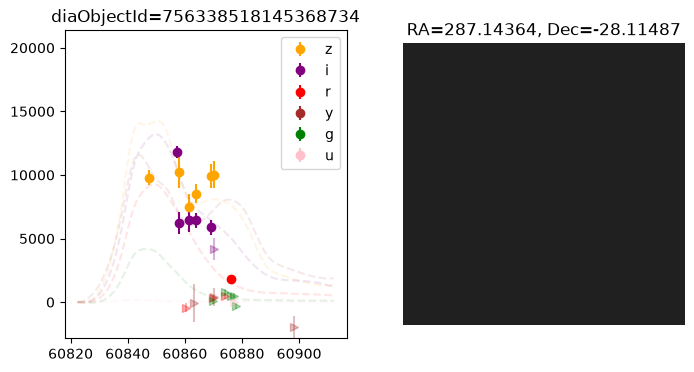

{'x0': 4.220675832741385e-05, 'x1': -2.4530523624017624, 'c': 0.14747588398135852, 'z': 0.10820638638357477, 'mwebv': 0.0782627532829265, 't0': 60868.49819559371}
dist,reduced_chi2= 3.2176678368375993 4.739325343622432


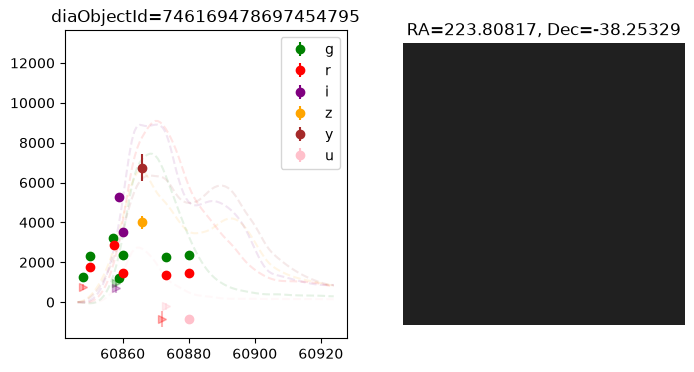

{'x0': 8.933270855458686e-06, 'x1': 0.9812790407609394, 'c': 0.07221981821975665, 'z': 0.4071066833940968, 'mwebv': 0.00601057520989239, 't0': 60858.631753473586}
dist,reduced_chi2= 4.019710884373935 1.523571330000704


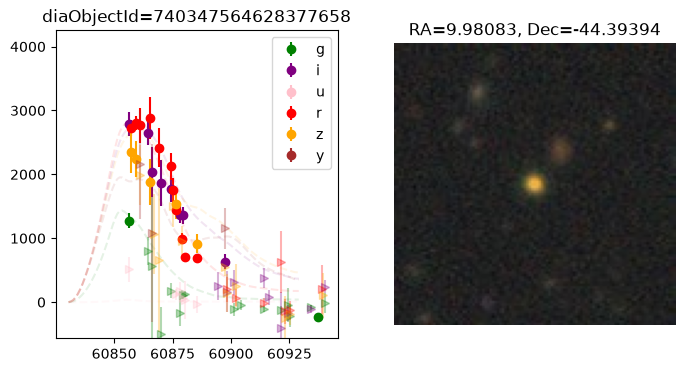

{'x0': 1.5765688819294862e-05, 'x1': 1.9136923506747265, 'c': 0.08491054078737847, 'z': 0.307247760515113, 'mwebv': 0.0776166009891449, 't0': 60866.8507328356}
dist,reduced_chi2= 2.6625677235959313 4.280103216060569


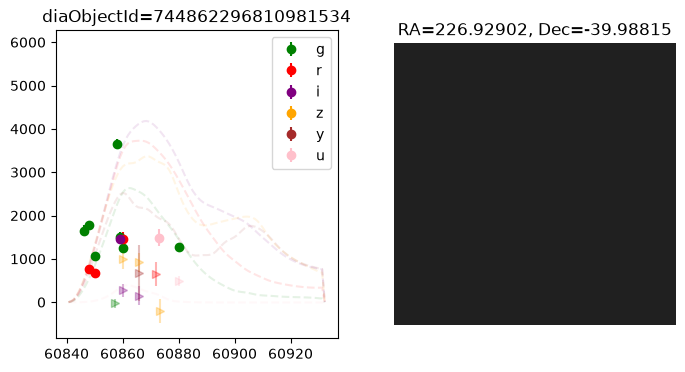

{'x0': 2.9371582903166938e-05, 'x1': -3.579517105621599, 'c': -0.37163316906730653, 'z': 0.30020840705133794, 'mwebv': 0.08250248809974801, 't0': 60839.23701113661}
dist,reduced_chi2= 4.410690284988463 3.8905429085606977


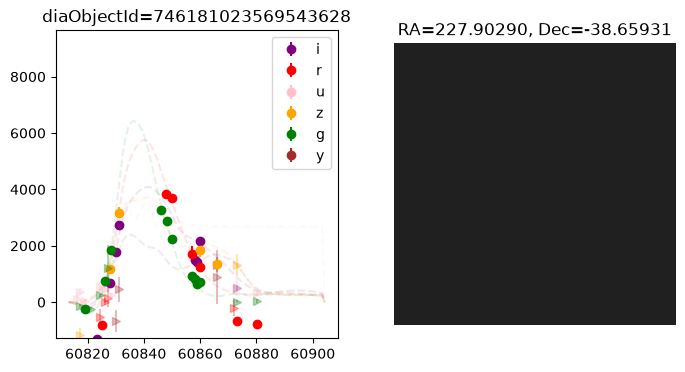

{'x0': 5.162778356826837e-05, 'x1': -2.0409801822498643, 'c': -0.27528067617724256, 'z': 0.4043021554714742, 'mwebv': 0.06563461937381002, 't0': 60892.40437441925}
dist,reduced_chi2= 0.10280842707651162 2.797183405562223


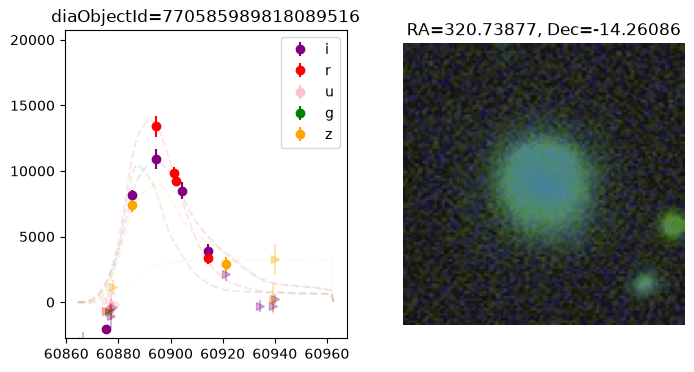

{'x0': 2.4438702867243122e-05, 'x1': 2.112042639753885, 'c': 0.3085934047603401, 'z': 0.40877685120975726, 'mwebv': 0.08882305262783632, 't0': 60868.22141692975}
dist,reduced_chi2= 3.5750331724111657 1.6731850779235067


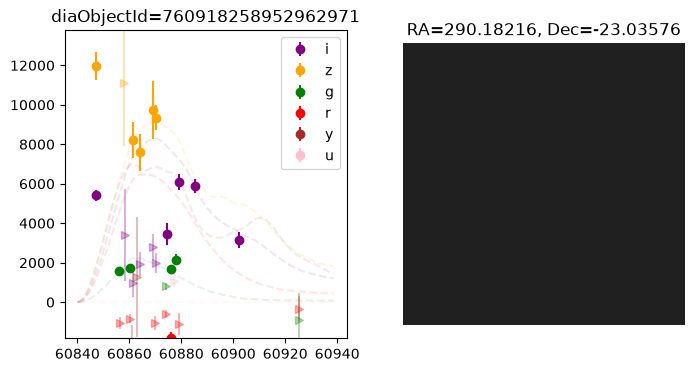

{'x0': -1.6806337079294146e-05, 'x1': -0.5310125930231638, 'c': -0.15180229906905718, 'z': 0.4860282424988003, 'mwebv': 0.07163476261555235, 't0': 60867.176575749494}
dist,reduced_chi2= 4.038621484053903 3.176071425051194


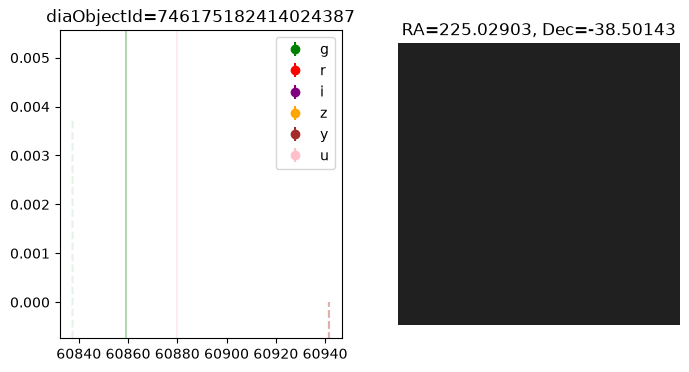

{'x0': 1.3184085533827982e-05, 'x1': 0.3628786332819164, 'c': -0.03275950166783517, 'z': 0.2839455618428516, 'mwebv': 0.007691000485669668, 't0': 60879.07140555529}
dist,reduced_chi2= 0.9438318259693211 0.8790633880010401


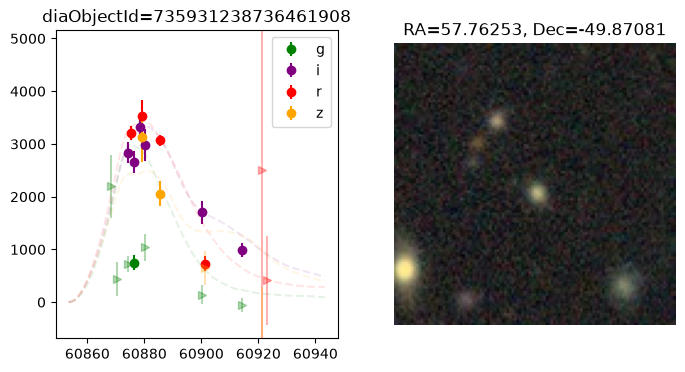

{'x0': 1.6898471730614288e-05, 'x1': 3.3729117056866214, 'c': 0.22321835214346478, 'z': 0.029967886058326135, 'mwebv': 0.08216829982085055, 't0': 60863.886783610484}
dist,reduced_chi2= 1.0053632791797922 2.416356081386757


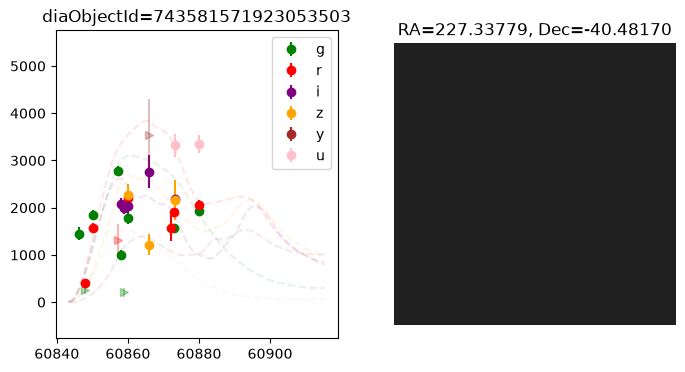

{'x0': 1.607707105268471e-05, 'x1': 1.820903200075056, 'c': -0.001124019784450588, 'z': 0.24188941263580682, 'mwebv': 0.07024881964419337, 't0': 60868.93230575152}
dist,reduced_chi2= 0.9681347020221682 4.232649145425467


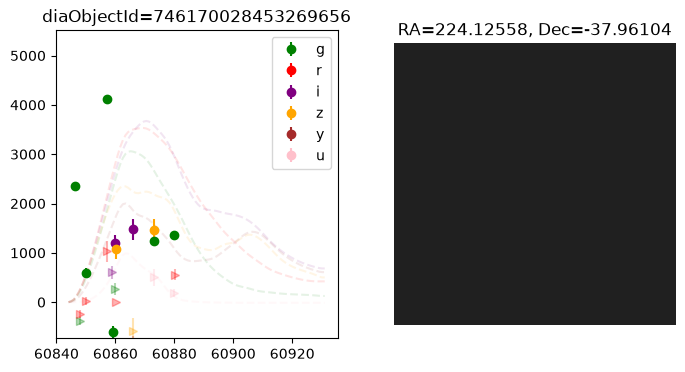

{'x0': 2.4750938696418734e-05, 'x1': 2.304509192460766, 'c': 0.27265570890792995, 'z': 0.10880258513138513, 'mwebv': 0.1476347375405454, 't0': 60832.43362019039}
dist,reduced_chi2= 4.389225532467656 1.8454196571014634


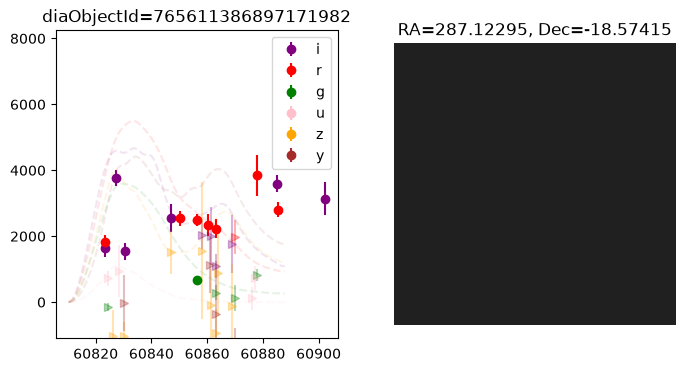

{'x0': 1.611005578364239e-05, 'x1': -1.2016093663541918, 'c': -0.19631375170983553, 'z': 0.6965026129554801, 'mwebv': 0.09223207556331452, 't0': 60867.58416647447}
dist,reduced_chi2= 0.8910706006141785 0.48112592576165164


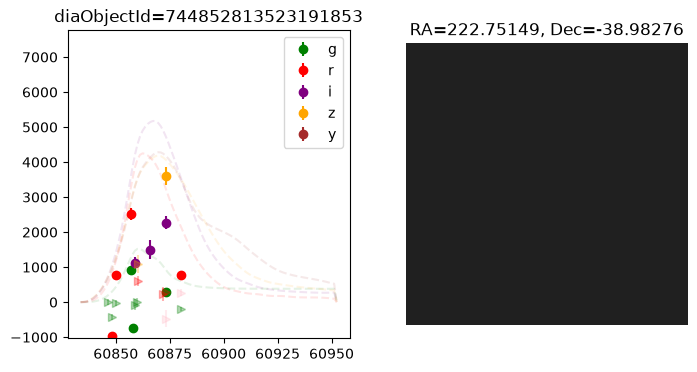

{'x0': 1.597768204944932e-05, 'x1': 0.26768952823477427, 'c': -0.21172544111227992, 'z': 0.11538739059587398, 'mwebv': 0.07453380032911297, 't0': 60864.85964042852}
dist,reduced_chi2= 4.569374308737093 1.7104839923264301


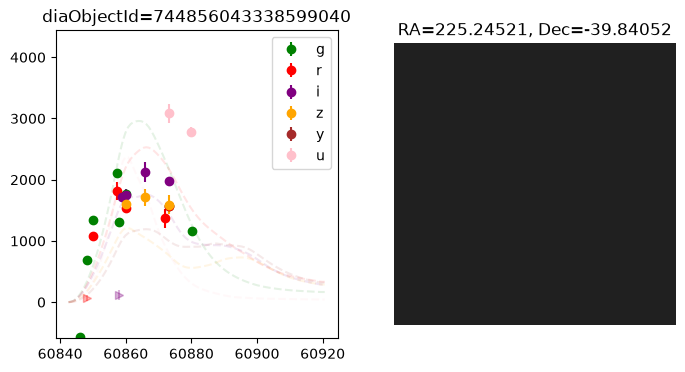

{'x0': 1.3979792568639922e-05, 'x1': -1.5183837013071717, 'c': -0.00787344811842071, 'z': 0.49097925836712253, 'mwebv': 0.06199285457495303, 't0': 60865.452138955596}
dist,reduced_chi2= 3.797653445999616 4.71397435032163


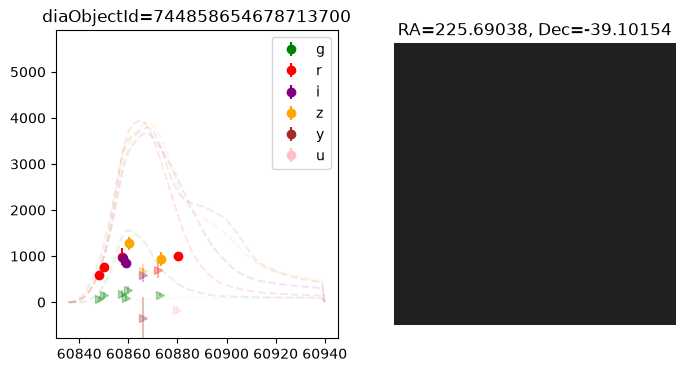

{'x0': 1.2939270611108694e-05, 'x1': 1.892979887786925, 'c': 0.28125009756547803, 'z': 0.6229380704644844, 'mwebv': 0.08617236029965553, 't0': 60861.46812140252}
dist,reduced_chi2= 4.780721609409028 1.726074407908959


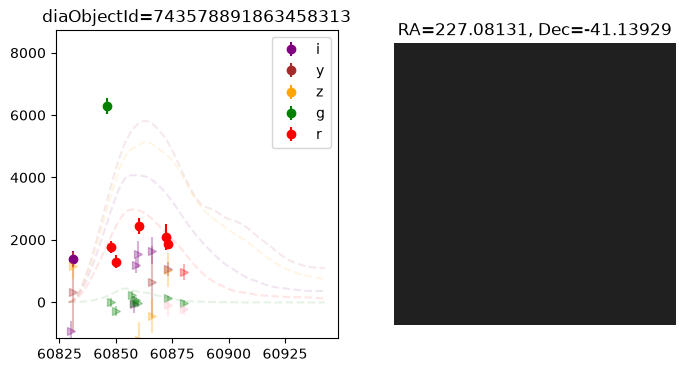

{'x0': 1.2585596050427696e-05, 'x1': -2.5969179814094128, 'c': 0.25061549989327375, 'z': 0.2910615531932601, 'mwebv': 0.07343386808362878, 't0': 60862.032882006824}
dist,reduced_chi2= 1.4360087949446099 1.0208343054253737


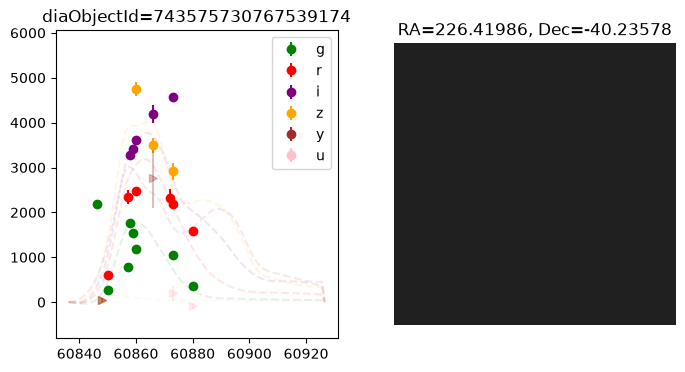

{'x0': 1.147180591110166e-05, 'x1': -0.2912316303645173, 'c': -8.47239801511358e-06, 'z': 0.3307500693513516, 'mwebv': 0.015790226234263037, 't0': 60886.86856576113}
dist,reduced_chi2= 1.183303242241243 1.7827409055948384


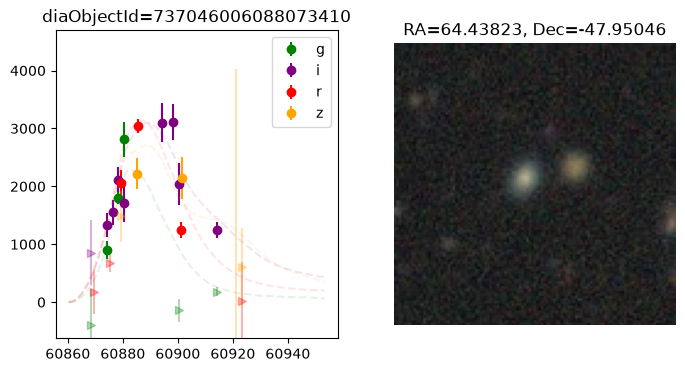

{'x0': 1.926837959518893e-05, 'x1': 0.14026744006139596, 'c': 0.15159234647474334, 'z': 0.3258702237947351, 'mwebv': 0.07746806992745171, 't0': 60867.93033141994}
dist,reduced_chi2= 4.588650340751233 4.297561250030124


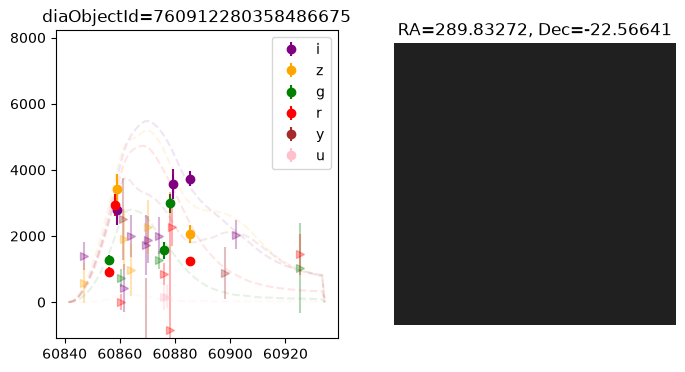

{'x0': 9.637713881194074e-06, 'x1': 2.9171321034280324, 'c': 0.2519267546559809, 'z': 0.1788887114128385, 'mwebv': 0.09203307238028718, 't0': 60861.24490477989}
dist,reduced_chi2= 4.789737963967905 1.8120807702442727


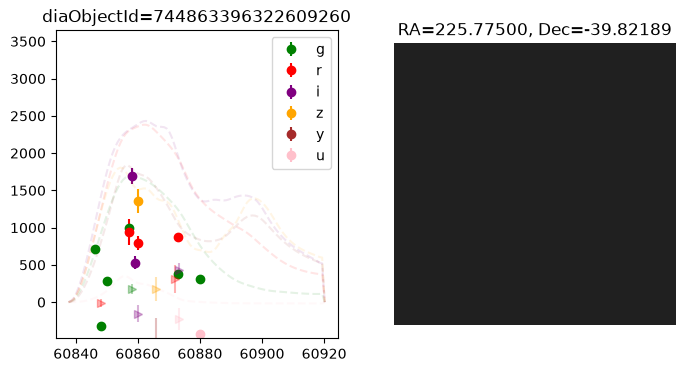

{'x0': 1.8135404049360476e-05, 'x1': -0.31840301540644306, 'c': -0.15161394897437686, 'z': 0.3059574612364224, 'mwebv': 0.07464822052277557, 't0': 60866.622386669296}
dist,reduced_chi2= 4.5352222844738055 2.844489981710576


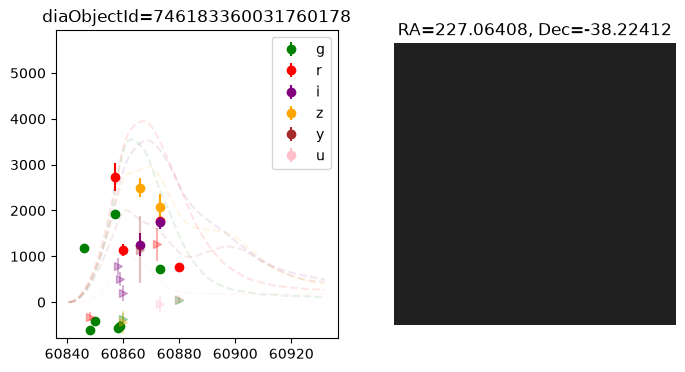

{'x0': 2.642984996820965e-05, 'x1': 3.4580726403503754, 'c': 0.05761597656427077, 'z': 0.02952121720726742, 'mwebv': 0.06509605092831358, 't0': 60828.5607514608}
dist,reduced_chi2= 4.499760673636844 3.387734986521581


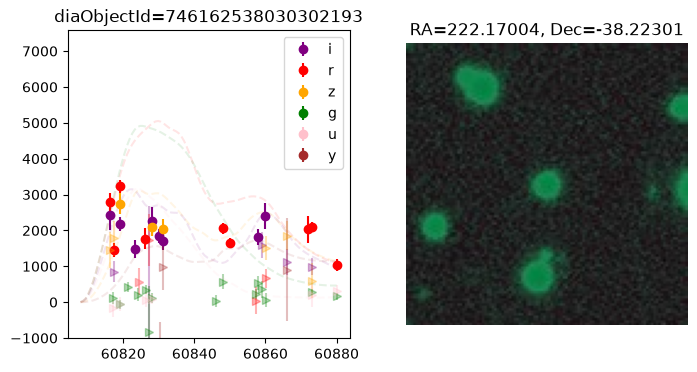

{'x0': 2.1573109193042214e-05, 'x1': -2.571940963509633, 'c': 0.17813525986982093, 'z': 5.9390498495750885e-09, 'mwebv': 0.08535144639716988, 't0': 60855.50783693603}
dist,reduced_chi2= 3.5857819177551917 4.041956106193199


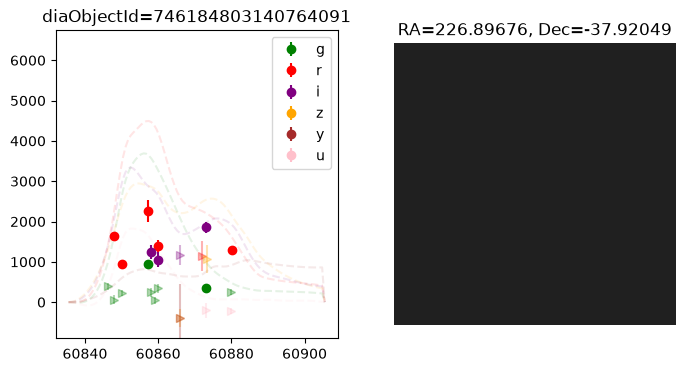

In [99]:
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([50,len(sn)]),replace=False):
    saltpars_df = result_good.loc[result_good.id==sn.iloc[i]["diaObjectId_dia_object_lc"]]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col].values[0]
    print(saltpars)
    print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], sn.iloc[i]["reduced_chisq"])
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -20) & (phase < 70)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    lc_coadd = nightly_coadd(lc["mjd"],lc["band"],lc["flux"],lc["fluxerr"])
    lc_coadd["snr"] = lc_coadd["flux"]/lc_coadd["fluxerr"]
    plot_lc(lc_coadd,saltpars=saltpars)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax = plt.subplot(1,2,2)
    ra = sn.iloc[i]["ra_dia_object_lc"]
    dec = sn.iloc[i]["dec_dia_object_lc"]
    img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [98]:
print(list(sn["diaObjectId_dia_object_lc"]))

[772323012031545366, 775608215336386996, 782292146521636893, 760904171460231444, 762454620294348839, 760904102740756800, 760904102740755469, 760912074200056966, 760906095605579830, 762461286083593424, 760907057678254320, 762453726941152488, 762461698400454183, 762455032611210108, 762462454314698393, 762455788525454326, 762455651086502327, 762456544439697628, 762466371324871241, 762456132122839817, 762450290967314525, 762451871515280437, 762458262426615894, 762458812182430900, 762459980413536611, 764029670701138741, 764022042839220419, 764021974119744640, 764022661314511660, 764023279789803504, 764023211070325104, 764023211070326031, 764031938443873513, 764032007163347372, 762465477971673489, 762466714922257005, 764035030820323784, 764035099539800621, 762466233885921187, 764035305698230384, 764036061612476033, 764036680087765071, 764035580576139056, 764044376669159612, 764036954965672812, 764038466794160791, 764043414596485830, 764039703744743357, 765633652007636453, 764036061612477148,